# Flight Price Analytics: what drives airline ticket prices?

**Author:** Jeremiah Dibie

Analysis of ~300,000 flight booking records from EaseMyTrip (India's top 6 metro cities) to understand what drives ticket prices, followed by a linear regression model to predict them.

**Dataset:** [Flight Price Prediction (Kaggle)](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction). Download `Clean_Dataset.csv` into the `data/` folder before running.

**Business questions**
1. Does price vary with airline?
2. How is the price affected when tickets are bought just 1 or 2 days before departure?
3. Does price change with departure and arrival time?
4. How does price change with source and destination city?
5. How does price vary between Economy and Business class?

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 80

## 1. Load and inspect the data

In [2]:
data = pd.read_csv('../data/Clean_Dataset.csv', usecols=lambda col: col != 'Unnamed: 0')
data.head(10)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB


In [4]:
data.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [5]:
data.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

## 2. Data transformation
Convert flight duration from hours to minutes, and price from Indian rupees to US dollars (1 INR = 0.012 USD, rate on 29/04/2024).

In [6]:
# Convert the duration in hours to duration in minutes
data['duration_minutes'] = data['duration'] * 60

# Convert the price from Indian rupees to US dollars
data['price_usd'] = data['price'] * 0.012
data.head(10)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,duration_minutes,price_usd
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,130.2,71.436
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,139.8,71.436
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,130.2,71.472
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,135.0,71.460
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,139.8,71.460
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955,139.8,71.460
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060,124.8,72.720
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060,130.2,72.720
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954,130.2,71.448
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954,135.0,71.448


## 3. Exploratory data analysis

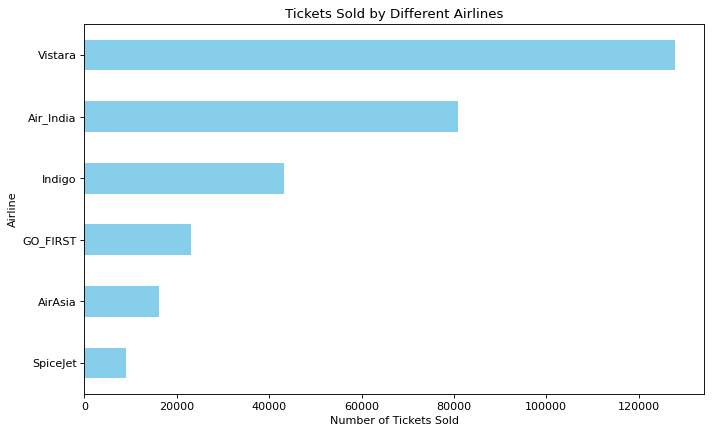

In [7]:
# Tickets sold by airline
plt.figure(figsize=(10, 6))
data['airline'].value_counts().plot(kind='barh', color='skyblue')
plt.title('Tickets Sold by Different Airlines')
plt.xlabel('Number of Tickets Sold')
plt.ylabel('Airline')
plt.gca().invert_yaxis()  # highest count on top
plt.show()

### Q1. Does price vary with airline?

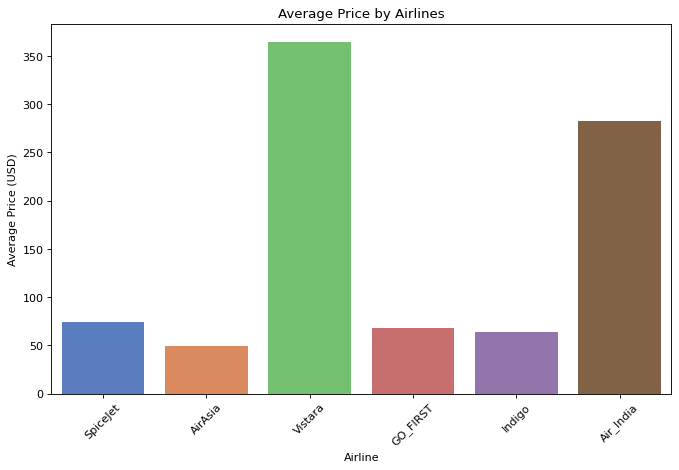

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x='airline', y='price_usd', data=data, errorbar=None, palette='muted')
plt.title('Average Price by Airlines')
plt.xlabel('Airline')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.show()

### Q2. How is the price affected when tickets are bought 1 or 2 days before departure?

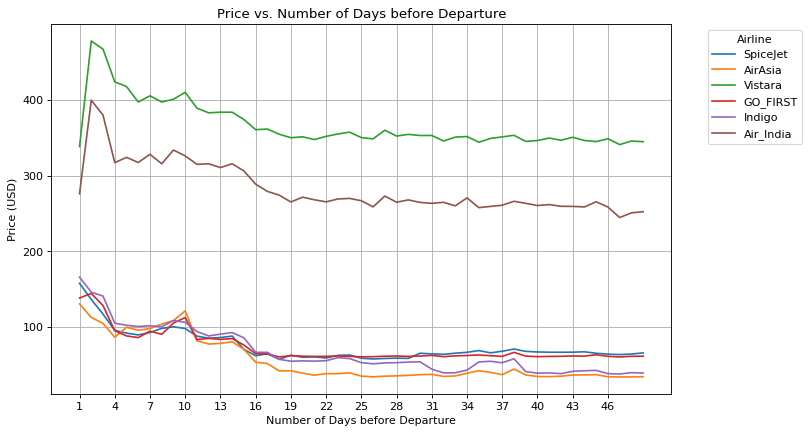

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='days_left', y='price_usd', hue='airline', data=data, errorbar=None)
plt.title('Price vs. Number of Days before Departure')
plt.ylabel('Price (USD)')
plt.xlabel('Number of Days before Departure')
plt.xticks(range(data['days_left'].min(), data['days_left'].max(), 3))
plt.legend(title='Airline', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# With one or two days left before departure, tickets cost more than at any other point, whatever
# the airline. Vistara and Air India are the exception on the final day: their last-day prices
# are noticeably lower than two days out, which suggests a different pricing strategy.

### Q3. Does ticket price change with departure and arrival time?

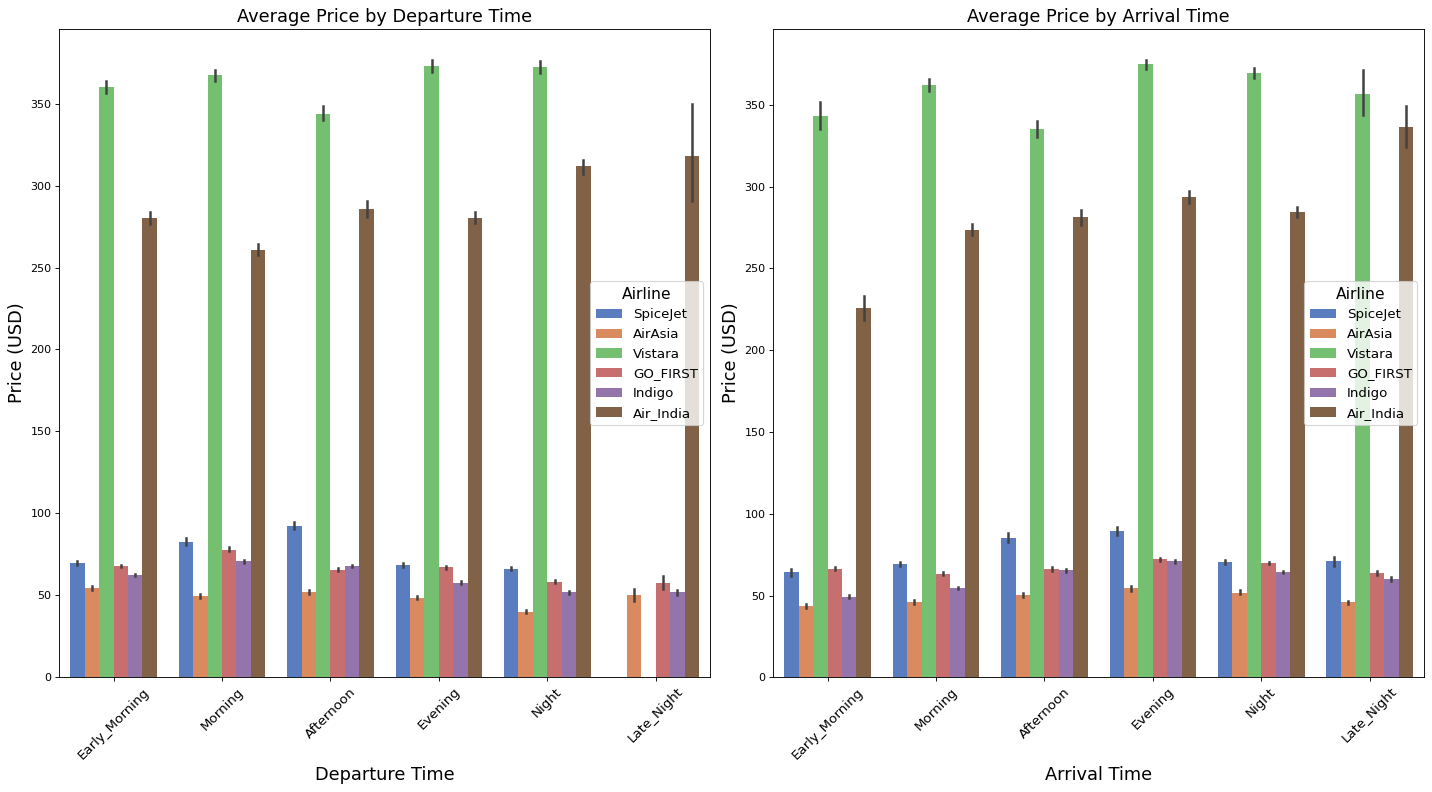

In [10]:
time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']

plt.figure(figsize=(18, 10))
plt.subplot(1, 2, 1)
sns.barplot(x='departure_time', y='price_usd', hue='airline', order=time_order, data=data, palette='muted')
plt.xlabel('Departure Time', fontsize=16)
plt.ylabel('Price (USD)', fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.title('Average Price by Departure Time', fontsize=16)
plt.legend(title='Airline', fontsize=12, title_fontsize=14)

plt.subplot(1, 2, 2)
sns.barplot(x='arrival_time', y='price_usd', hue='airline', order=time_order, data=data, palette='muted')
plt.xlabel('Arrival Time', fontsize=16)
plt.ylabel('Price (USD)', fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.title('Average Price by Arrival Time', fontsize=16)
plt.legend(title='Airline', fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()

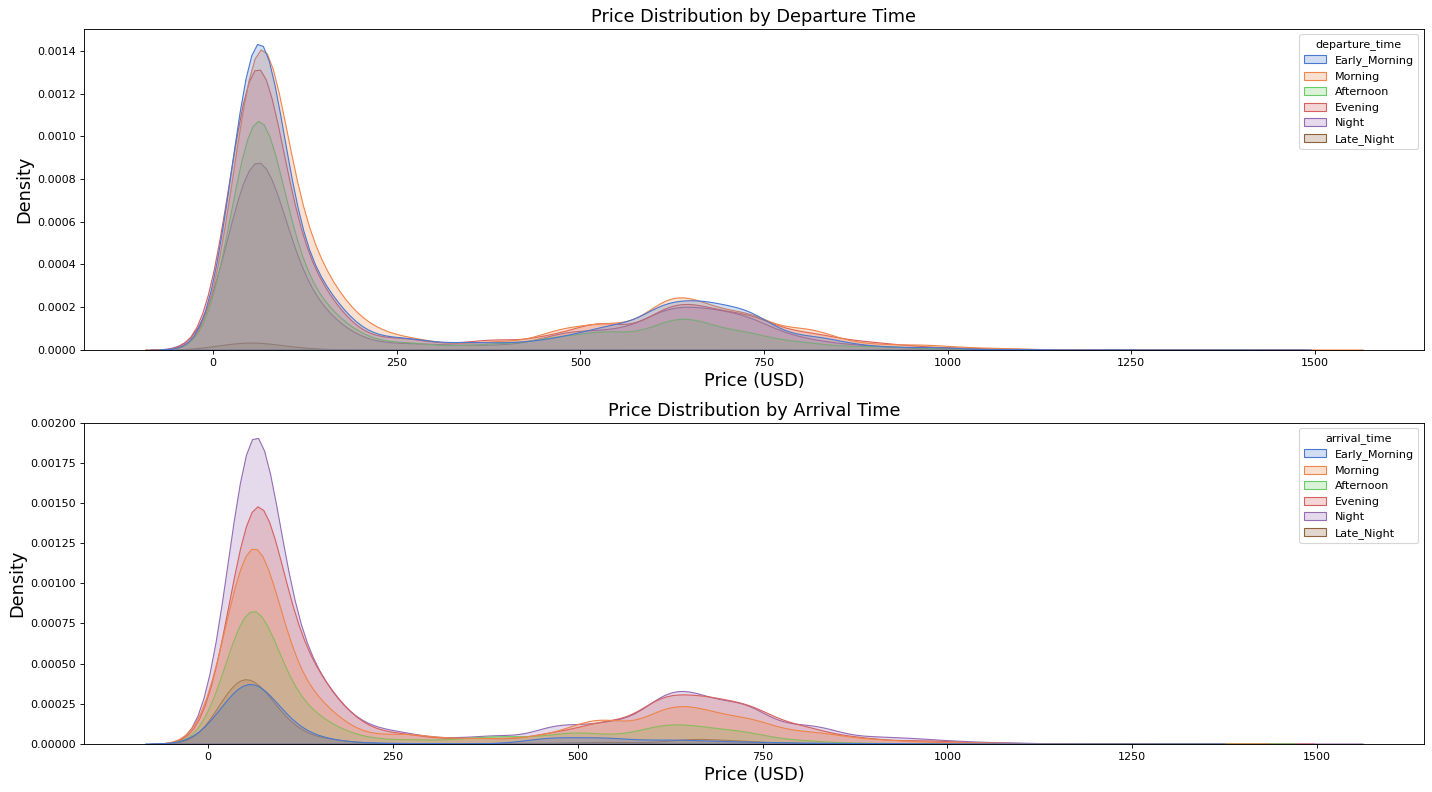

In [11]:
# Price distribution by departure and arrival time
plt.figure(figsize=(18, 10))
plt.subplot(2, 1, 1)
sns.kdeplot(x='price_usd', hue='departure_time', data=data, hue_order=time_order, fill=True, palette='muted')
plt.title('Price Distribution by Departure Time', fontsize=16)
plt.xlabel('Price (USD)', fontsize=16)
plt.ylabel('Density', fontsize=16)

plt.subplot(2, 1, 2)
sns.kdeplot(x='price_usd', hue='arrival_time', data=data, hue_order=time_order, fill=True, palette='muted')
plt.title('Price Distribution by Arrival Time', fontsize=16)
plt.xlabel('Price (USD)', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.tight_layout()
plt.show()

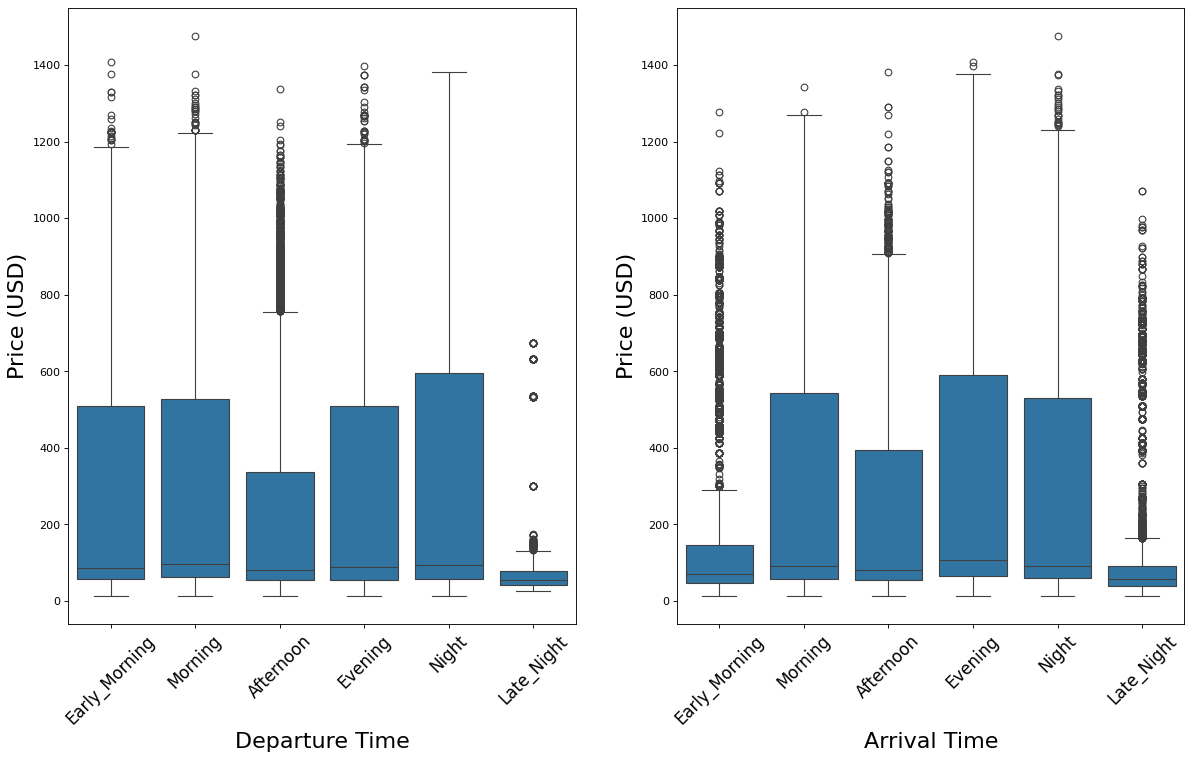

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
sns.boxplot(x='departure_time', y='price_usd', data=data, order=time_order, ax=ax1)
ax1.set_xlabel('Departure Time', fontsize=20)
ax1.set_ylabel('Price (USD)', fontsize=20)
ax1.tick_params(axis='x', labelsize=15, rotation=45)

sns.boxplot(x='arrival_time', y='price_usd', data=data, order=time_order, ax=ax2)
ax2.set_xlabel('Arrival Time', fontsize=20)
ax2.set_ylabel('Price (USD)', fontsize=20)
ax2.tick_params(axis='x', labelsize=15, rotation=45)
plt.show()

# Flights departing or arriving late at night are cheaper. The distributions are far from normal,
# but the conclusion holds on the medians, which are robust to extreme values.

### Q4. How does price change with source and destination city?

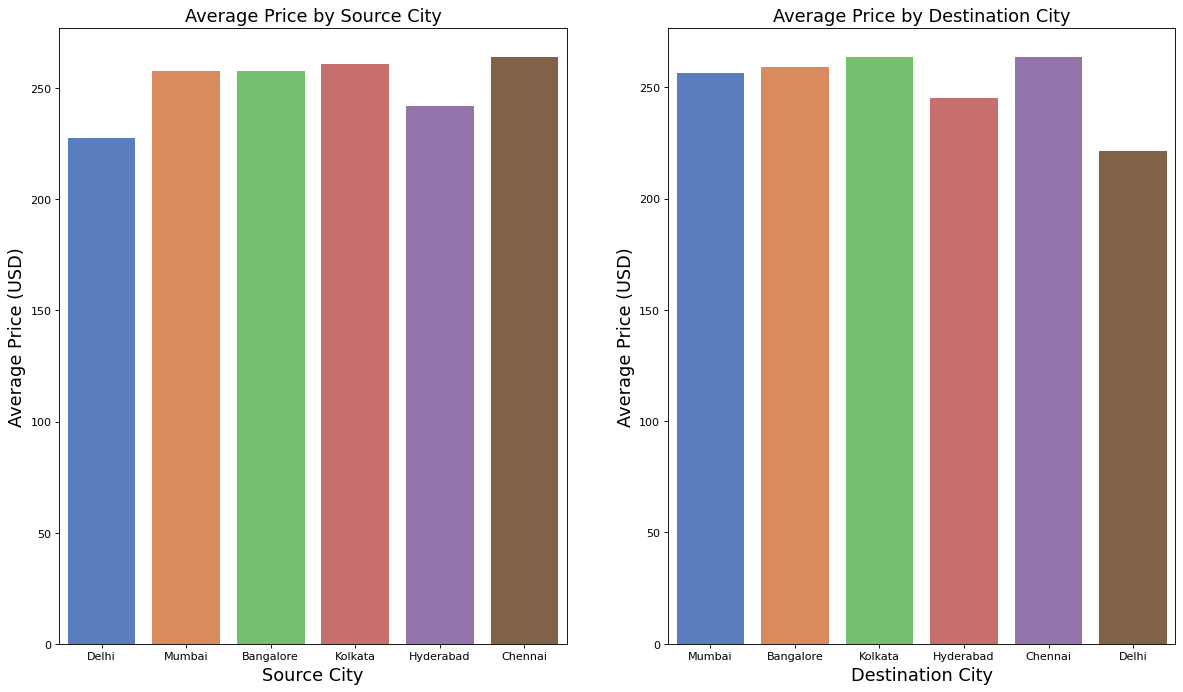

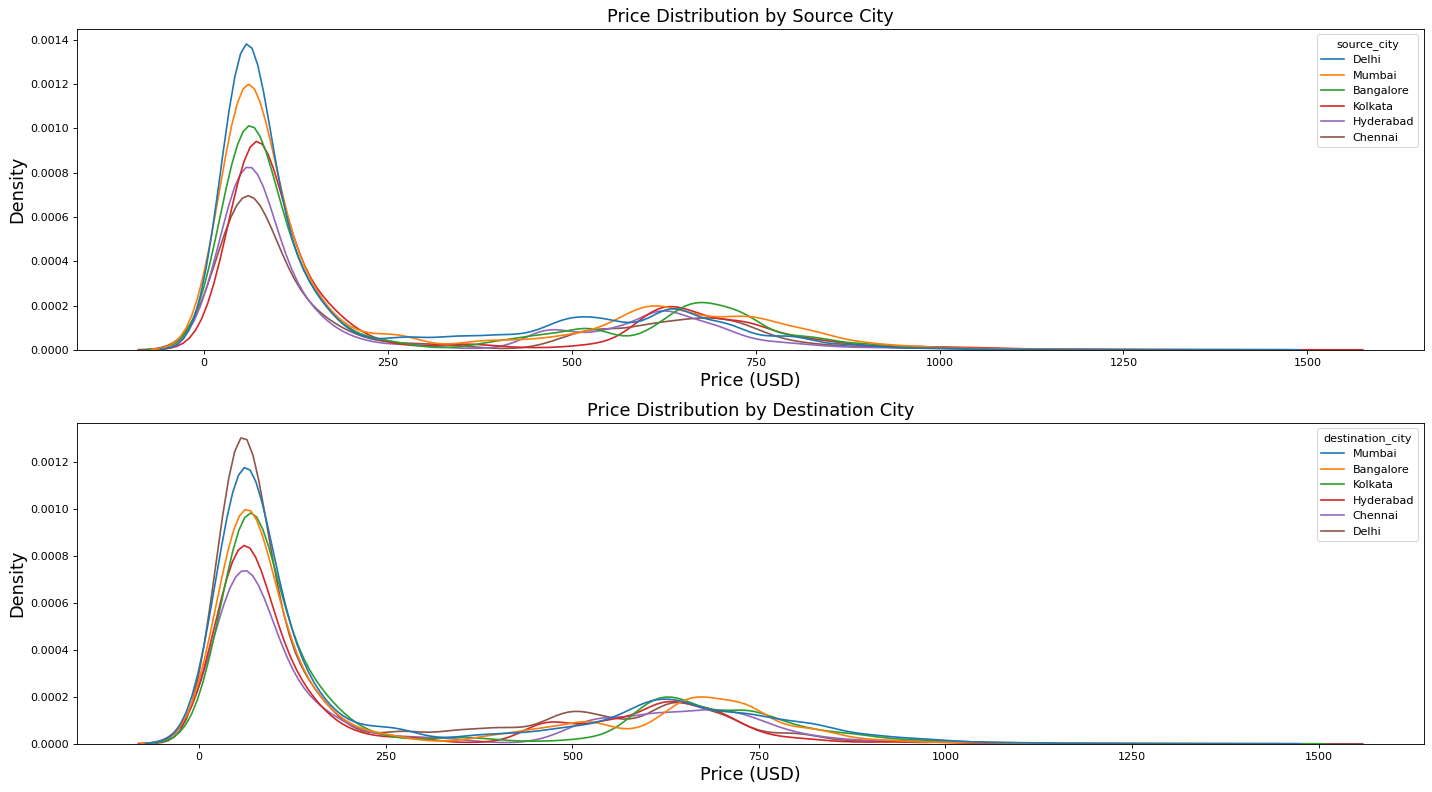

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
sns.barplot(x='source_city', y='price_usd', data=data, ax=ax1, errorbar=None, palette='muted')
ax1.set_xlabel('Source City', fontsize=16)
ax1.set_ylabel('Average Price (USD)', fontsize=16)
ax1.set_title('Average Price by Source City', fontsize=16)

sns.barplot(x='destination_city', y='price_usd', data=data, ax=ax2, errorbar=None, palette='muted')
ax2.set_xlabel('Destination City', fontsize=16)
ax2.set_ylabel('Average Price (USD)', fontsize=16)
ax2.set_title('Average Price by Destination City', fontsize=16)
plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10))
sns.kdeplot(x='price_usd', hue='source_city', data=data, ax=ax1)
ax1.set_title('Price Distribution by Source City', fontsize=16)
ax1.set_xlabel('Price (USD)', fontsize=16)
ax1.set_ylabel('Density', fontsize=16)

sns.kdeplot(x='price_usd', hue='destination_city', data=data, ax=ax2)
ax2.set_title('Price Distribution by Destination City', fontsize=16)
ax2.set_xlabel('Price (USD)', fontsize=16)
ax2.set_ylabel('Density', fontsize=16)
plt.tight_layout()
plt.show()

# Prices vary with both source and destination city, which may reflect distance,
# route popularity and supply and demand.

### Q5. How does price vary between Economy and Business class?

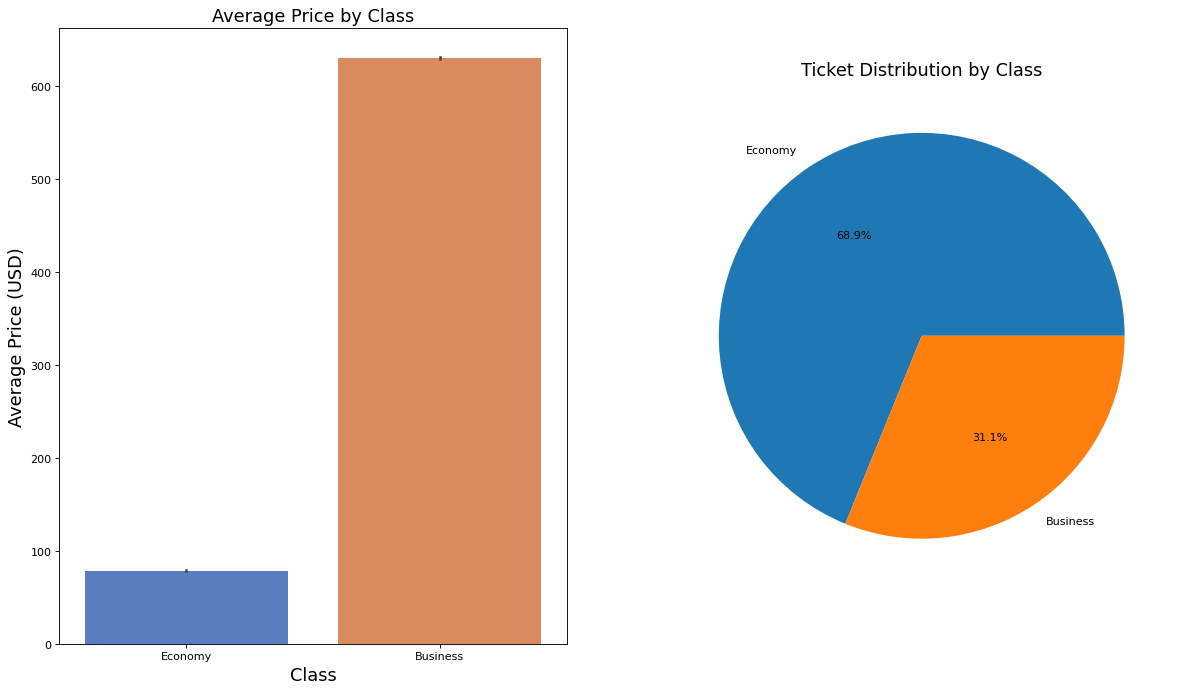

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
sns.barplot(x='class', y='price_usd', data=data, ax=ax1, palette='muted')
ax1.set_xlabel('Class', fontsize=16)
ax1.set_ylabel('Average Price (USD)', fontsize=16)
ax1.set_title('Average Price by Class', fontsize=16)

data['class'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax2)
ax2.set_ylabel('')
ax2.set_title('Ticket Distribution by Class', fontsize=16)
plt.show()

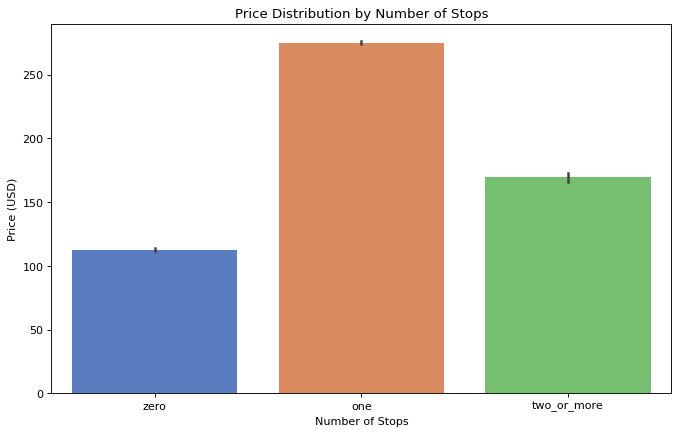

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x='stops', y='price_usd', data=data, palette='muted')
plt.title('Price Distribution by Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Price (USD)')
plt.show()

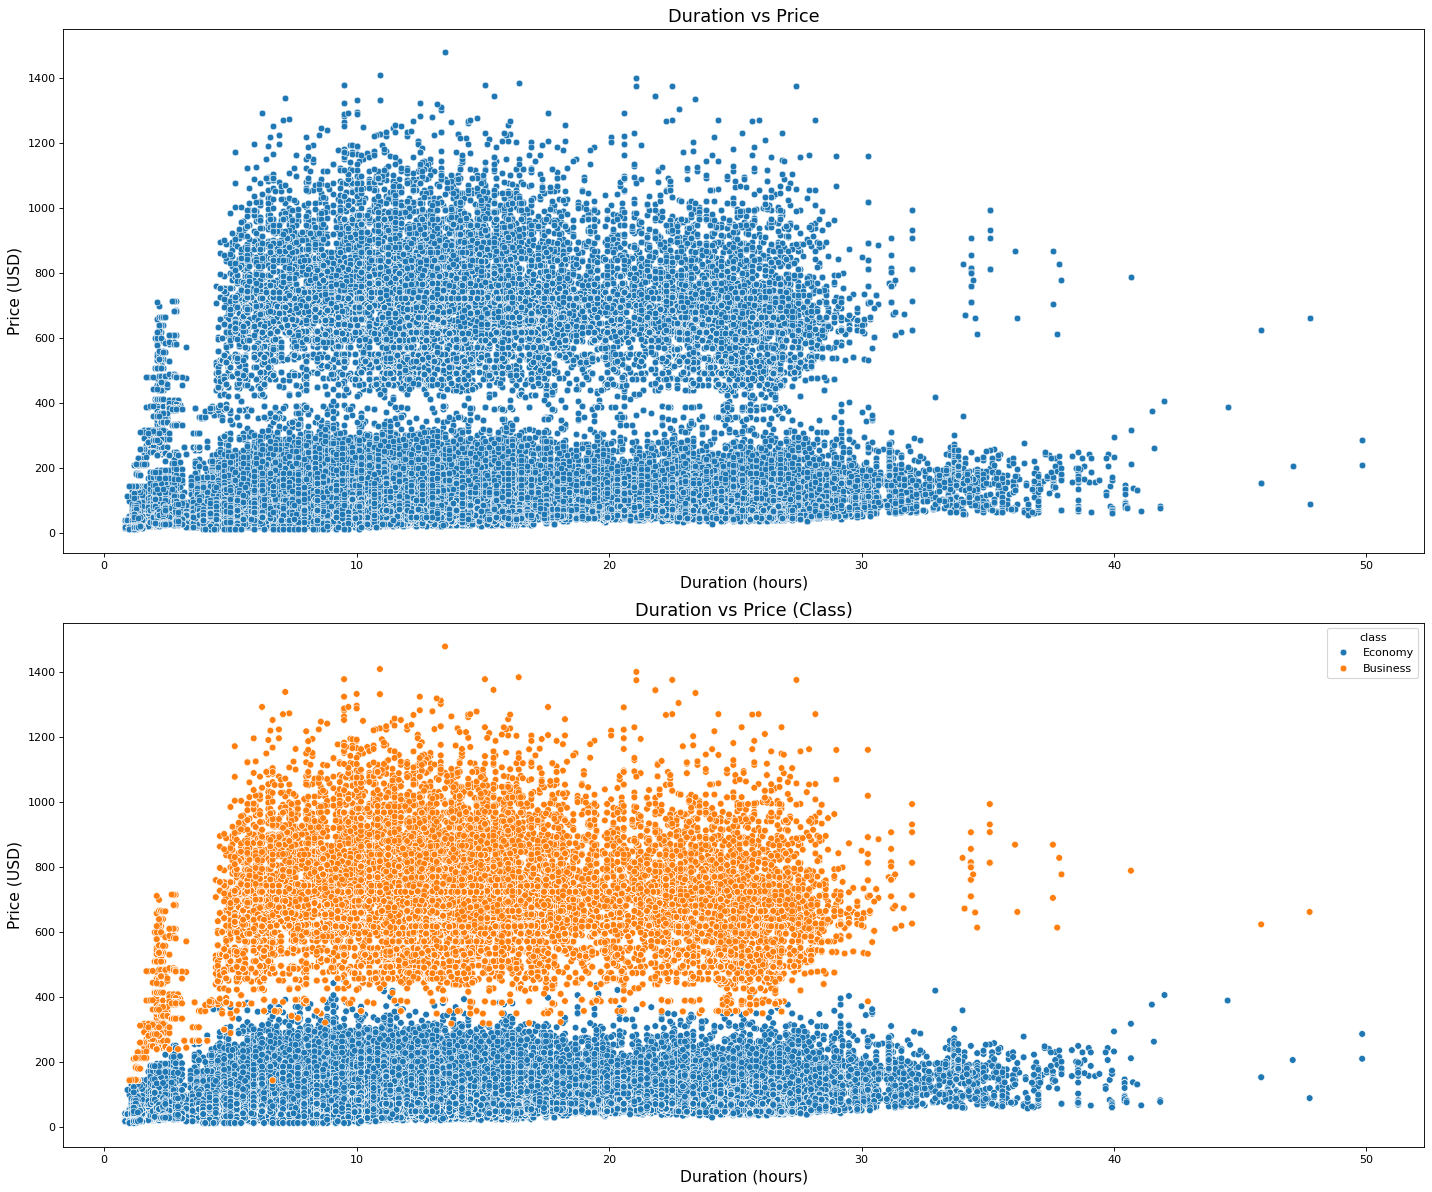

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 15))
sns.scatterplot(x='duration', y='price_usd', data=data, ax=ax1)
ax1.set_title('Duration vs Price', fontsize=16)
ax1.set_xlabel('Duration (hours)', fontsize=14)
ax1.set_ylabel('Price (USD)', fontsize=14)

sns.scatterplot(x='duration', y='price_usd', hue='class', data=data, ax=ax2)
ax2.set_title('Duration vs Price (Class)', fontsize=16)
ax2.set_xlabel('Duration (hours)', fontsize=14)
ax2.set_ylabel('Price (USD)', fontsize=14)
plt.tight_layout()
plt.show()

# Duration alone shows no clear relationship with price. Adding class separates the two clusters:
# for the same duration, Business tickets cost far more than Economy.

## 4. Predicting price with linear regression

In [17]:
# Encode categorical variables
label_encoder = LabelEncoder()
data['airline_num'] = label_encoder.fit_transform(data['airline'])
data['class_num'] = label_encoder.fit_transform(data['class'])
data['stops_num'] = label_encoder.fit_transform(data['stops'])

# Define predictors and target variable
X = data[['airline_num', 'class_num', 'stops_num', 'duration_minutes']]
y = data['price_usd']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [18]:
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f"Train Mean Squared Error: {train_mse:.2f}")
print(f"Test Mean Squared Error: {test_mse:.2f}")
print(f"Train Mean Absolute Error: {train_mae:.2f}")
print(f"Test Mean Absolute Error: {test_mae:.2f}")
print(f"Train R-squared: {train_r2:.2f}")
print(f"Test R-squared: {test_r2:.2f}")

Train Mean Squared Error: 7555.54
Test Mean Squared Error: 7580.14
Train Mean Absolute Error: 59.02
Test Mean Absolute Error: 58.85
Train R-squared: 0.90
Test R-squared: 0.90


In [19]:
# Compare actual and predicted prices
results_train = pd.DataFrame({'Actual Price (USD)': y_train, 'Predicted Price (USD)': y_pred_train})
results_test = pd.DataFrame({'Actual Price (USD)': y_test, 'Predicted Price (USD)': y_pred_test})
results_train['Price Difference (USD)'] = results_train['Actual Price (USD)'] - results_train['Predicted Price (USD)']
results_test['Price Difference (USD)'] = results_test['Actual Price (USD)'] - results_test['Predicted Price (USD)']

print("Training Data - Actual vs Predicted Price:")
print(results_train.head(20))
print("\nTesting Data - Actual vs Predicted Price:")
print(results_test.head(20))

Training Data - Actual vs Predicted Price:
        Actual Price (USD)  Predicted Price (USD)  Price Difference (USD)
148417             162.288              79.830056               82.457944
36879              119.280              48.681584               70.598416
274531             671.796             617.304339               54.491661
166397              95.124             114.245494              -19.121494
272722             666.024             670.458941               -4.434941
183550              62.472             108.210190              -45.738190
47422               62.784             107.357235              -44.573235
255047             746.256             665.186128               81.069872
200793              87.744              77.180724               10.563276
37174               51.012              86.175525              -35.163525
190559              55.644             108.429891              -52.785891
43344              180.936             106.814446               74.12

## 5. Conclusions

- **Class is the biggest driver of price.** Business tickets average about \$630 against about \$79 for Economy, roughly 8 times more.
- **Booking late is expensive.** Economy fares one day before departure average about \$175, roughly 3 times the \$57–64 paid three or more weeks out. Vistara and Air India are the exception: their prices dip on the final day.
- **Late-night flights are the cheapest.** The median late-night departure costs about \$54, against \$80–97 for other times of day.
- **Vistara and Air India are the premium carriers**, averaging about \$365 and \$282. AirAsia is the cheapest at about \$49.
- **Non-stop flights are the cheapest on average in both classes** (Economy: about \$48 non-stop against \$82 with one stop). Non-stop routes tend to be shorter, so the number of stops partly stands in for distance.
- **Linear regression explains about 90% of price variance (test R² = 0.90, MAE ≈ \$59)** using only airline, class, stops and duration. The largest errors are on Business-class fares, which suggests non-linear models such as gradient boosting would improve on it.